# Tutorial para [cmblensplus](https://toshiyan.github.io/clpdoc/html/index.html)

La idea es usar este paquete para hacer delensing interno.
En adelante usaremos los mapas de r = 0 (sin foreground, ni ruido)

In [ ]:
import os
import numpy as np
import healpy as hp
import matplotlib.pyplot as plt

# ---------------
# Ruta de los mapas
# ---------------

ruta = "/home/jorge/Escritorio/Proy_cosmo/Cosmo_MSc/camb_outputs/fiducial/r_0.0/"

nside = 512
lmax = 1000

ells = np.loadtxt(os.path.join(ruta, "ells.txt"))
Cl_phiphi = np.loadtxt(os.path.join(ruta, "Cl_phiphi.txt"))
Cl_total_BB = np.loadtxt(os.path.join(ruta, "Cl_total_BB.txt"))
Cl_total_EE = np.loadtxt(os.path.join(ruta, "Cl_total_EE.txt"))
Cl_total_TE = np.loadtxt(os.path.join(ruta, "Cl_total_TE.txt"))
Cl_total_TT = np.loadtxt(os.path.join(ruta, "Cl_total_TT.txt"))
Cl_unlensed_BB = np.loadtxt(os.path.join(ruta, "Cl_unlensed_BB.txt"))
Cl_unlensed_EE = np.loadtxt(os.path.join(ruta, "Cl_unlensed_EE.txt"))
Cl_unlensed_TT = np.loadtxt(os.path.join(ruta, "Cl_unlensed_TT.txt"))
Cl_unlensed_TE = np.loadtxt(os.path.join(ruta, "Cl_unlensed_TE.txt"))

map_phiphi = hp.read_map(os.path.join(ruta, "map_phiphi.fits"))
map_total_Q = hp.read_map(os.path.join(ruta, "map_total_Q.fits"))
map_total_T = hp.read_map(os.path.join(ruta, "map_total_T.fits"))
map_total_U = hp.read_map(os.path.join(ruta, "map_total_U.fits"))

map_unlensed_Q = hp.read_map(os.path.join(ruta, "map_unlensed_Q.fits"))
map_unlensed_T = hp.read_map(os.path.join(ruta, "map_unlensed_T.fits"))
map_unlensed_U = hp.read_map(os.path.join(ruta, "map_unlensed_U.fits"))


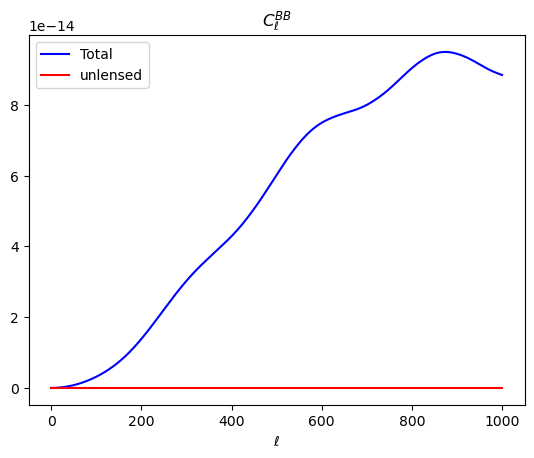

In [2]:
factor = ells*(ells+1)/(2*np.pi)

plt.plot(ells,Cl_total_BB*factor, color='b', label='Total')
plt.plot(ells,Cl_unlensed_BB*factor, color='r', label='unlensed')
plt.xlabel(r'$\ell$')
plt.title(r'$C_\ell^{BB}$')
plt.legend()
plt.show()

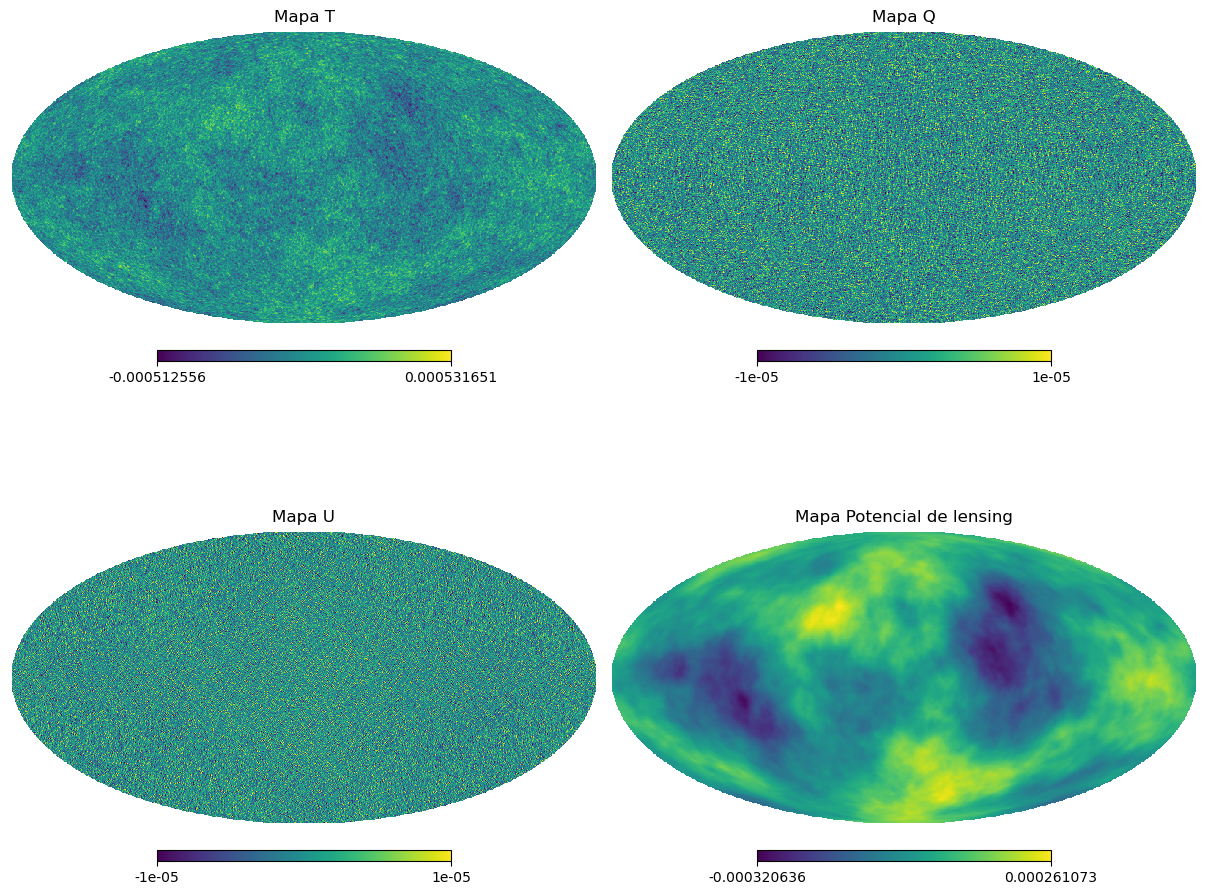

In [3]:
plt.figure(figsize=(12,10))

hp.mollview(map_total_T, title="Mapa T",sub=(2,2,1))
hp.mollview(map_total_Q, title="Mapa Q",min=-1e-5,max=1e-5,sub=(2,2,2))
hp.mollview(map_total_U, title="Mapa U",min=-1e-5,max=1e-5,sub=(2,2,3))
hp.mollview(map_phiphi, title="Mapa Potencial de lensing",sub=(2,2,4))
plt.show()

De los mapas anteriores me queda la pregunta si este mapa del potencial de lensing logra lensear el mapa unlensed de CAMB y llegar a los mapas totales que estoy graficando... 

Primero transformaremos los mapas Q y U en E y B. 

Y para chequear que es correcto compararemos los Cl's



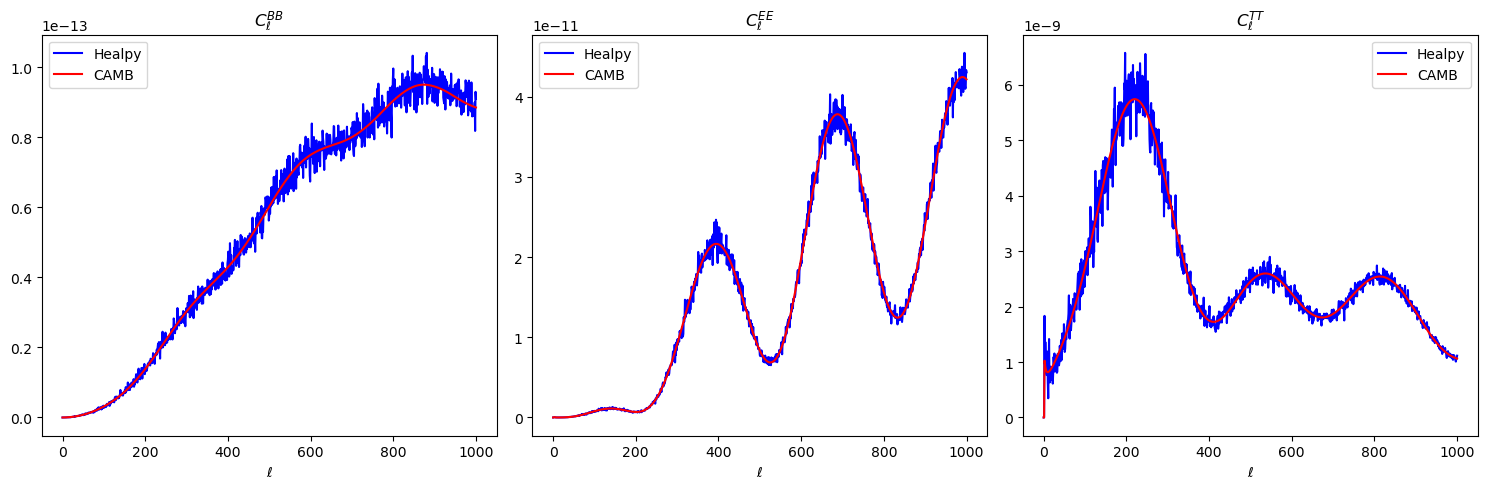

In [4]:
#Para graficar los D_l
factor = ells*(ells+1)/(2*np.pi)

#Transforma los mapas T en alm
alm_total_T = hp.map2alm(map_total_T, lmax=lmax, use_pixel_weights=True)

#Transforma de los mapas Q y U en los alm de spin 2 
alm_total_E, alm_total_B = hp.sphtfunc.map2alm_spin(np.array([map_total_Q,map_total_U]), spin=2, lmax=lmax)

#Verifiquemos que los Cls son similares a los del CAMB
Cl_BB = hp.sphtfunc.alm2cl(alm_total_B,alm_total_B,lmax=lmax)*factor
Cl_EE = hp.sphtfunc.alm2cl(alm_total_E,alm_total_E,lmax=lmax)*factor
Cl_TT = hp.sphtfunc.alm2cl(alm_total_T,alm_total_T,lmax=lmax)*factor

fig, ax = plt.subplots(1, 3, figsize=(15, 5))

ax[0].plot(ells,Cl_BB,color='b',label='Healpy') 
ax[0].plot(ells, Cl_total_BB*factor,color="r",label='CAMB')
ax[0].set_title(r'$C_\ell^{BB}$')
ax[0].legend()
ax[0].set_xlabel(r'$\ell$')

ax[1].plot(ells,Cl_EE,color='b',label='Healpy') 
ax[1].plot(ells, Cl_total_EE*factor,color="r",label='CAMB')
ax[1].set_title(r'$C_\ell^{EE}$')
ax[1].legend()
ax[1].set_xlabel(r'$\ell$')

ax[2].plot(ells,Cl_TT,color='b',label='Healpy') 
ax[2].plot(ells, Cl_total_TT*factor,color="r",label='CAMB')
ax[2].set_title(r'$C_\ell^{TT}$')
ax[2].legend()
ax[2].set_xlabel(r'$\ell$')

plt.tight_layout()
plt.show()

#Transforma de los alm de spin 2 a mapas de E y B
map_total_E = hp.alm2map(alm_total_E, nside)
map_total_B = hp.alm2map(alm_total_B, nside)



ESTE 'RUIDO' SUPONGO QUE SE PUEDE ELIMINAR SI HACEMOS MAS REALIZACIONES ??


PARA añadir los [FOREGROUNDS VER ESTE LINK](https://www.zonca.dev/posts/2024-04-12-pysm-figures)

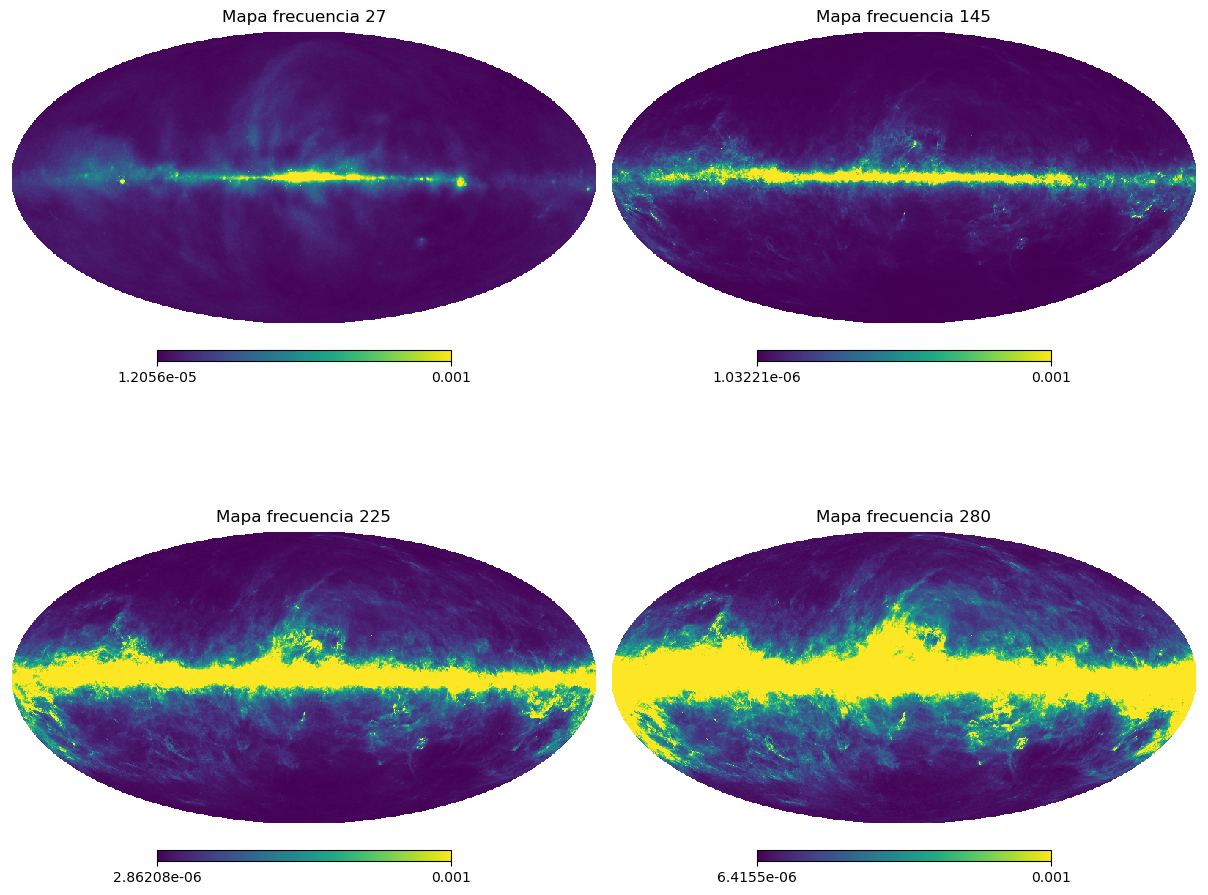

In [5]:
# Recuperar mapas de foreground DEBO REESCALARLO PQ TIENEN Nside = 1024 
ruta_f = "/home/jorge/Escritorio/Proy_cosmo/Cosmo_MSc/camb_outputs/fiducial/Foreground/Simple"

freq = np.array([27, 39, 93, 145, 225, 280])


list_map_fg_T = []
list_map_fg_Q = []
list_map_fg_U = []
list_alm_fg_T = []
list_alm_fg_Q = []
list_alm_fg_U = []
for i,f in enumerate(freq):
    map_T = hp.read_map(os.path.join(ruta_f, f"map_{freq[i]}_T.fits"))
    map_Q = hp.read_map(os.path.join(ruta_f, f"map_{freq[i]}_Q.fits"))
    map_U = hp.read_map(os.path.join(ruta_f, f"map_{freq[i]}_U.fits"))
    alm_fg_T = hp.map2alm(map_T, lmax=lmax, use_pixel_weights=True)
    list_alm_fg_T.append(alm_fg_T)
    list_map_fg_T.append(map_T)
    list_map_fg_Q.append(map_Q)
    list_map_fg_U.append(map_U)


plt.figure(figsize=(12,10))

hp.mollview(list_map_fg_T[0], title="Mapa frecuencia 27", max=1e-3, sub=(2,2,1))
hp.mollview(list_map_fg_T[3], title="Mapa frecuencia 145", max=1e-3,sub=(2,2,2))
hp.mollview(list_map_fg_T[4], title="Mapa frecuencia 225", max=1e-3,sub=(2,2,3))
hp.mollview(list_map_fg_T[5], title="Mapa frecuencia 280", max=1e-3,sub=(2,2,4))
plt.show()

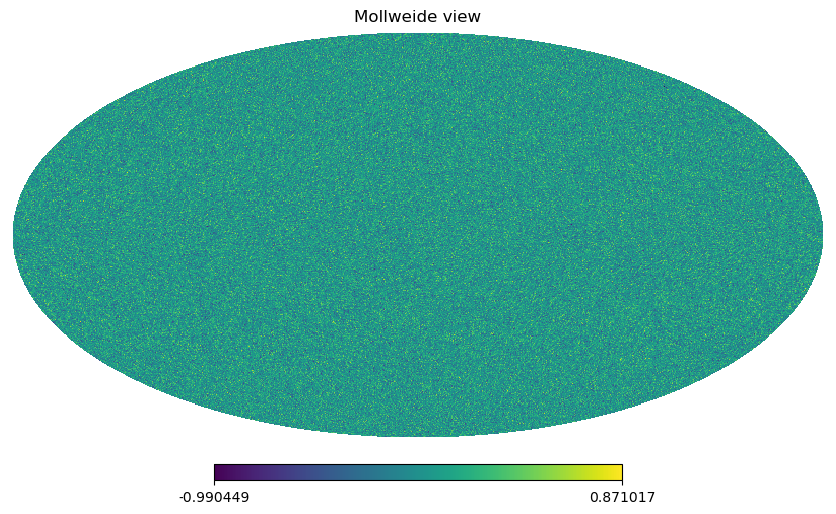

In [6]:
#Recuperamos mapas de ruido
ruta_n = "/home/jorge/Escritorio/Proy_cosmo/Cosmo_MSc/camb_outputs/fiducial/Noise_SO"

List_map = []
freq = np.array([27, 39, 93, 145, 225, 280])

for i,f in enumerate(freq):
    map = hp.read_map(os.path.join(ruta_n, f"map_{freq[i]}_LAT.fits"))
    List_map.append(map)

hp.mollview(List_map[0])


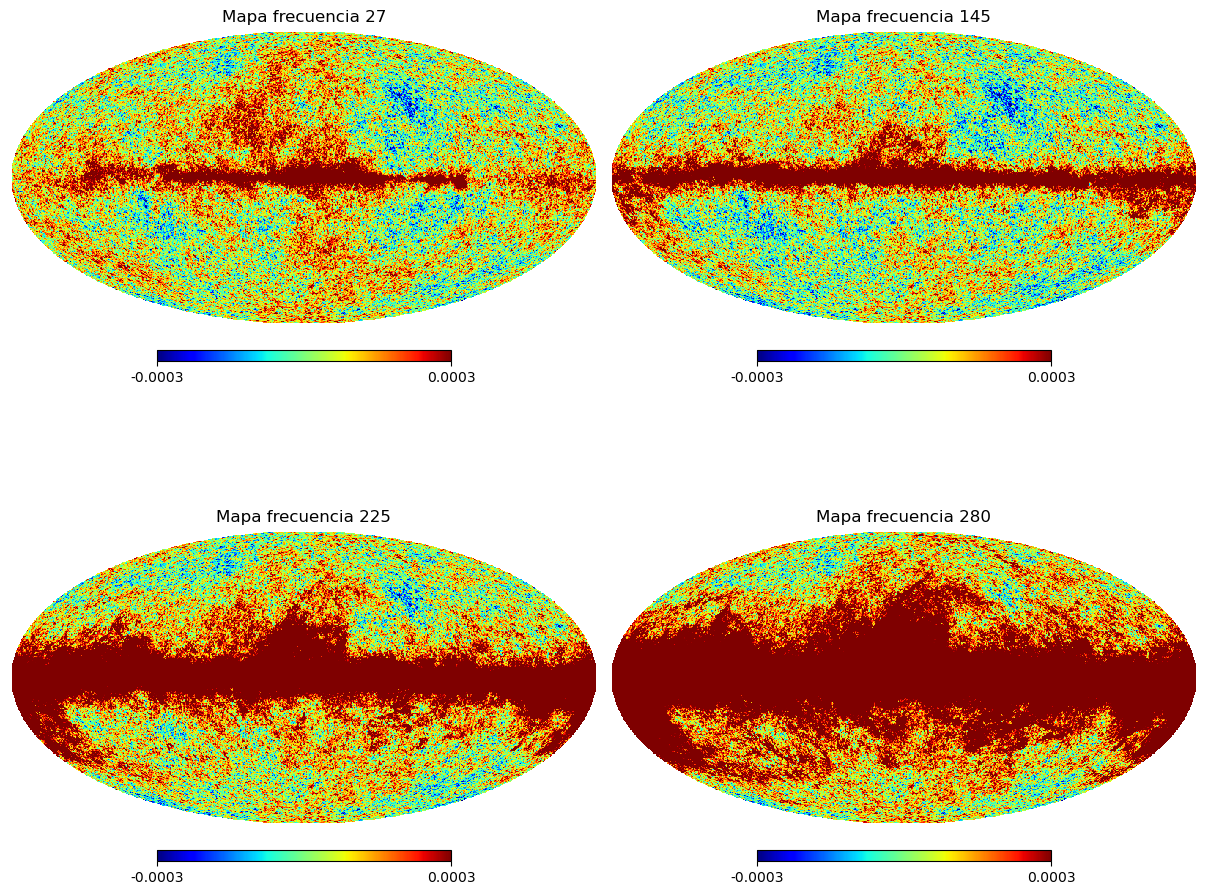

In [7]:
# Mapas CAMB + Foreground + NOISE 

list_map_obs_T = []
list_map_obs_E = []
list_map_obs_B = []
for i,f in enumerate(freq):
    map_obs_T =  list_map_fg_T[i] + map_total_T
    map_obs_Q =  list_map_fg_Q[i] + map_total_Q
    map_obs_U =  list_map_fg_U[i] + map_total_U

    list_map_obs_T.append(map_obs_T)
    list_map_obs_E.append(map_obs_Q)
    list_map_obs_B.append(map_obs_U)

plt.figure(figsize=(12,10))

hp.mollview(list_map_obs_T[0], title="Mapa frecuencia 27", min=-3e-4, max=3e-4, sub=(2,2,1), cmap = "jet")
hp.mollview(list_map_obs_T[3], title="Mapa frecuencia 145", min=-3e-4, max=3e-4,sub=(2,2,2), cmap = "jet")
hp.mollview(list_map_obs_T[4], title="Mapa frecuencia 225", min=-3e-4, max=3e-4,sub=(2,2,3), cmap = "jet")
hp.mollview(list_map_obs_T[5], title="Mapa frecuencia 280", min=-3e-4, max=3e-4,sub=(2,2,4), cmap = "jet")
plt.show()


## MAPA OBSERVADO

Recordemos que nos guiaremos de esta formula:

$$ a_{\ell m}^{\nu} = (a_{\ell m}^{s} + a_{\ell m}^{fg,\nu})B_\ell^{\nu}P_{\ell}^{W} + a_{\ell m}^{\nu} $$

por lo que haremos esta suma haremos el HILC para aplicar al final el wiener filter y ver que resulta.

Trabajaremos solamente con temperatura para aprender, pero luego debemos hacerlo para Q y U ---> E y B

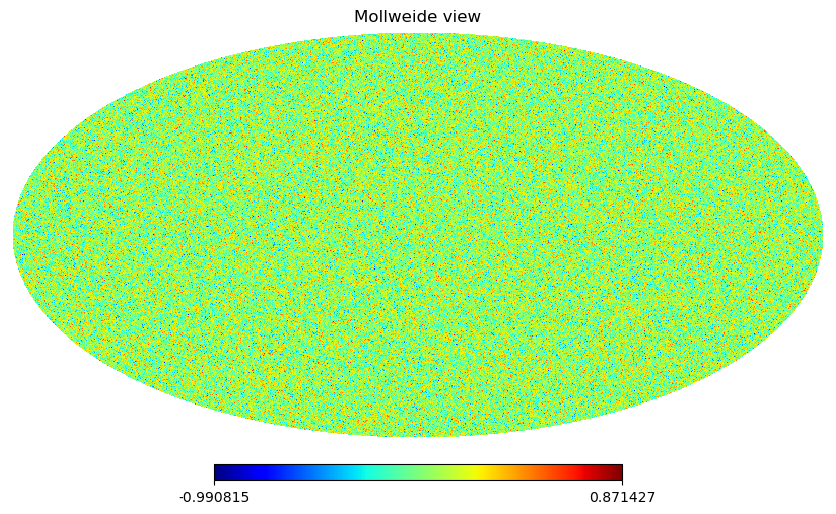

In [8]:
# Funcion Window depende solo de Nside 

w_pix = hp.pixwin(nside)

#Funcion Beam
FWHM = np.array([7.4, 5.1, 2.2, 1.4, 1.0, 0.9])*np.pi / (180 * 60) #en radianes

list_alm_obs_T = []
for i, fwhm in enumerate(FWHM):
    beam = hp.sphtfunc.gauss_beam(fwhm=FWHM[i], lmax=lmax)
    alm_noise = hp.map2alm(List_map[i], lmax=lmax, use_pixel_weights=True)
    alm_fg_s_T = alm_total_T + list_alm_fg_T[i]
    alm_beamed = hp.almxfl(alm_fg_s_T, beam)
    alm_window = hp.almxfl(alm_fg_s_T, w_pix)
    list_alm_obs_T.append(alm_window + alm_noise)

# Ver mapa de hacer el beam y window function
map_fg_s = hp.alm2map(list_alm_obs_T[0], nside=nside, lmax=lmax)

hp.mollview(map_fg_s, cmap = "jet") # min=-3e-4, max=3e-4,


#####  AÑADI RUIDO NO SE VA A VER NADA 

In [9]:

# Calculamos la matriz de covarianza entre diferentes frecuencias
nfreq = len(freq)
Cl = np.zeros((nfreq, nfreq, lmax+1))

for i in range(nfreq):
    for j in range(nfreq):
        Cl[i,j,:] = hp.alm2cl(list_alm_obs_T[i], list_alm_obs_T[j])

one = np.ones(nfreq) # vector de 1



In [10]:
# Pesos
weights = np.zeros((lmax+1, nfreq))

for ell in range(2, lmax+1):
    C = Cl[:,:,ell]           # matriz nfreq x nfreq
    Ci = np.linalg.inv(C)     # invierte la matriz
    num = Ci @ one
    den = one @ Ci @ one
    weights[ell,:] = num / den



In [ ]:

alm_clean = np.zeros_like(list_alm_obs_T[0])

for i in range(nfreq):
    alm_clean += list_alm_obs_T[i] * weights[:, i][:, None]



In [ ]:
map_obs_T = hp.alm2map(alm_clean, lmax=lmax, nside=nside)

hp.mollview(map_obs_T, cmap = "jet")

In [40]:
# AÑADIR FOREGROUNDS ---> como sumo CAMB + fore sin tienen resolucion distinta?
# AÑADIR RUIDO ---> Falta añadir ruido mas complejo 1/f
# Añadir mascaras de SO 
# HACER BEAM + WINDOW FUNCTION
# HACER Wiener Filter para quitar el ruido
# Hacer separacion de componentes para obtener el mapa 'observado limpio'
# Hacer delensing a ese mapa limpio 
#

In [45]:
a = np.array([1,2,3,4,5,6])

for i,j in enumerate(a):
    print(f'{i,j}')

(0, np.int64(1))
(1, np.int64(2))
(2, np.int64(3))
(3, np.int64(4))
(4, np.int64(5))
(5, np.int64(6))


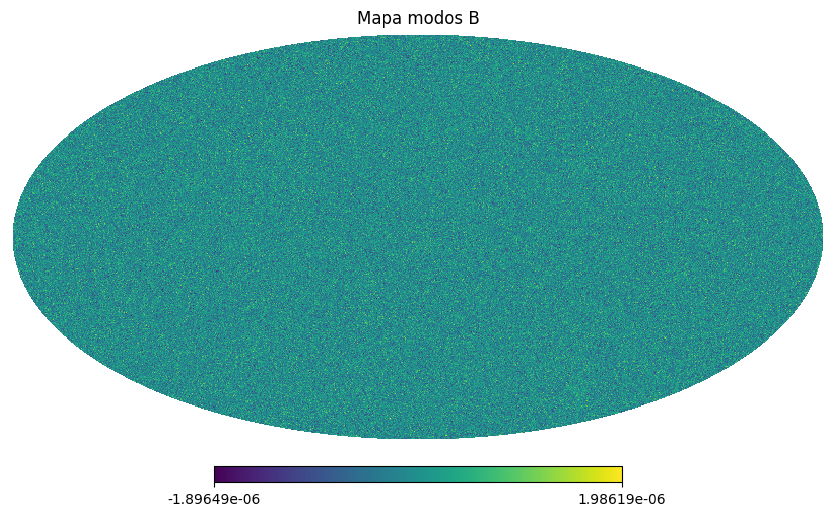

In [ ]:
plt.figure(figsize=(12,10))

hp.mollview(map_total_B, title="Mapa modos B",sub=(2,2,1))

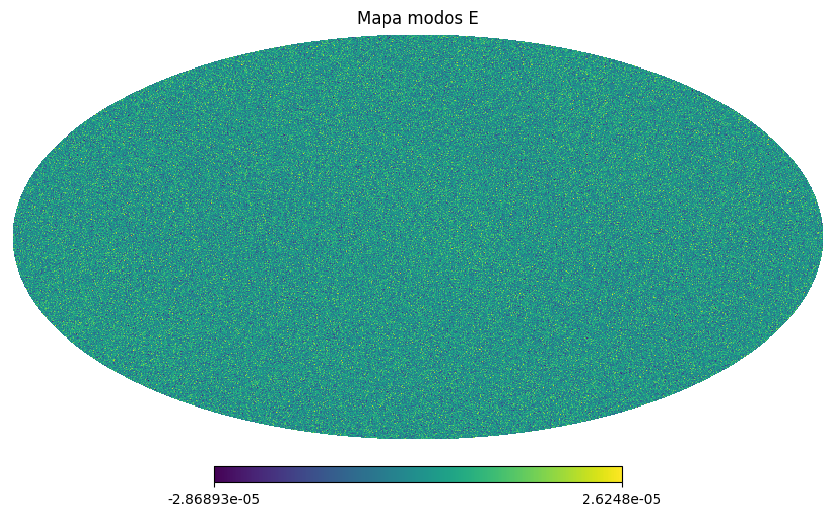

In [ ]:
hp.mollview(map_total_E, title="Mapa modos E",sub=(2,2,2))

In [11]:
# import sys
# sys.path.append("/home/jorge/cmblensplus")

from curvedsky import rec_lens

ImportError: cannot import name 'rec_lens' from 'curvedsky' (unknown location)

## FULL SKY


In [ ]:
# USAREMOS rec_lens --> Para la reconstruccion del estimador cuadratico

g_lm, c_lm = lens.